# March Machine Learning Mania 2026 — Data Exploration

Covers:
1. Data overview
2. Tournament seed matchup win rates (upset matrix)
3. Score margin distributions
4. Upset rates by round
5. Regular season predictors of tournament success
6. Score trends over time
7. Men's vs Women's comparison

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/landing'

m_tourney   = pl.read_csv(f'{DATA}/mens/MNCAATourneyCompactResults.csv')
m_tourney_d = pl.read_csv(f'{DATA}/mens/MNCAATourneyDetailedResults.csv')
m_regular   = pl.read_csv(f'{DATA}/mens/MRegularSeasonCompactResults.csv')
m_seeds     = pl.read_csv(f'{DATA}/mens/MNCAATourneySeeds.csv')
m_teams     = pl.read_csv(f'{DATA}/mens/MTeams.csv')

w_tourney   = pl.read_csv(f'{DATA}/womens/WNCAATourneyCompactResults.csv')
w_regular   = pl.read_csv(f'{DATA}/womens/WRegularSeasonCompactResults.csv')
w_seeds     = pl.read_csv(f'{DATA}/womens/WNCAATourneySeeds.csv')
w_teams     = pl.read_csv(f'{DATA}/womens/WTeams.csv')

print("Men's tournament games: ", len(m_tourney))
print("Men's regular season games:", len(m_regular))
print("Women's tournament games:", len(w_tourney))
print("Women's regular season games:", len(w_regular))
print("Seasons covered:", m_tourney['Season'].min(), '-', m_tourney['Season'].max())

Men's tournament games:  2585
Men's regular season games: 198079
Women's tournament games: 1717
Women's regular season games: 142093
Seasons covered: 1985 - 2025


## Helper

In [2]:
import re

def parse_seed(seed_str):
    m = re.search(r'(\d+)', seed_str)
    return int(m.group(1)) if m else None

## 1. Seed Win-Rate Matrix

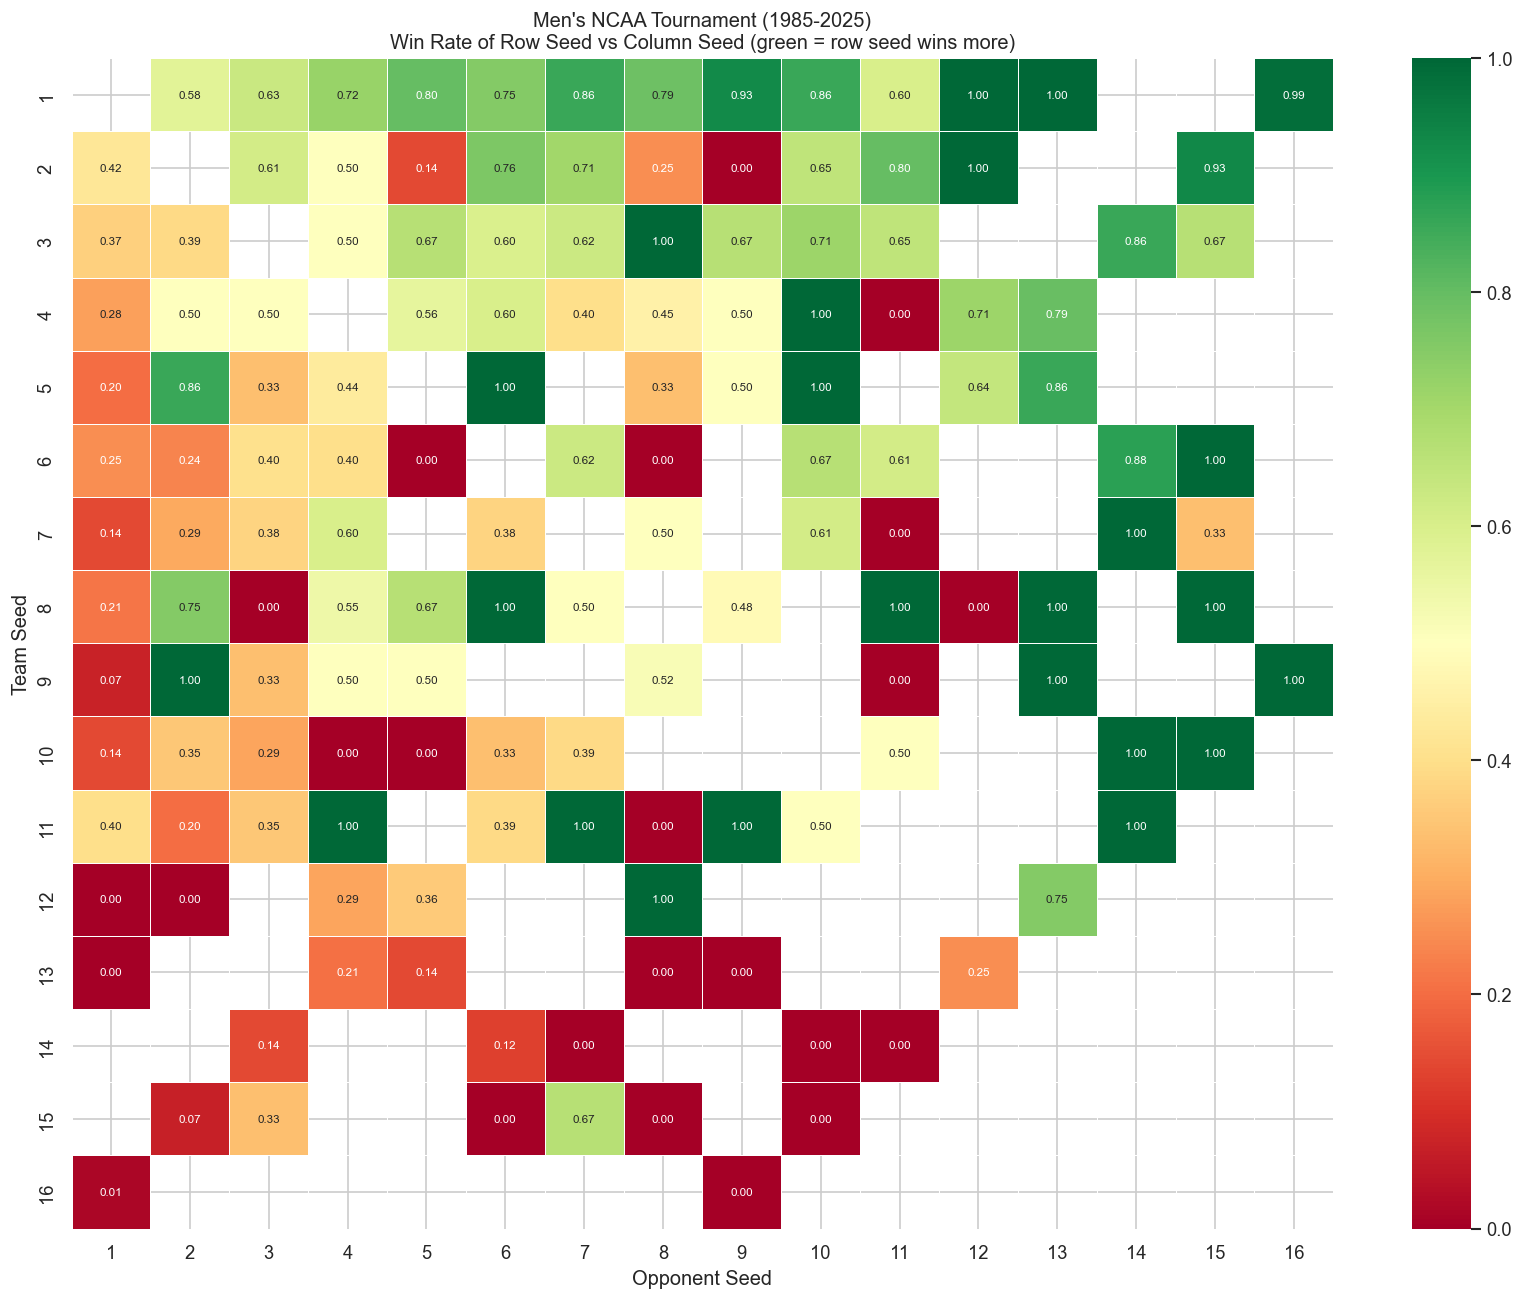

In [3]:
def build_seed_matrix(tourney, seeds, label):
    seed_map = (
        seeds
        .with_columns(pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum'))
        .select(['Season', 'TeamID', 'SeedNum'])
    )
    games = (
        tourney
        .join(seed_map.rename({'TeamID': 'WTeamID', 'SeedNum': 'WSeed'}), on=['Season', 'WTeamID'], how='left')
        .join(seed_map.rename({'TeamID': 'LTeamID', 'SeedNum': 'LSeed'}), on=['Season', 'LTeamID'], how='left')
        .drop_nulls(['WSeed', 'LSeed'])
    )
    seeds_range = list(range(1, 17))
    matrix = pd.DataFrame(np.nan, index=seeds_range, columns=seeds_range)
    for ws in seeds_range:
        for ls in seeds_range:
            if ws == ls:
                continue
            w = len(games.filter((pl.col('WSeed') == ws) & (pl.col('LSeed') == ls)))
            l = len(games.filter((pl.col('WSeed') == ls) & (pl.col('LSeed') == ws)))
            if w + l > 0:
                matrix.loc[ws, ls] = w / (w + l)

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                mask=matrix.isna(), ax=ax, linewidths=0.3, linecolor='white', annot_kws={'size': 7})
    ax.set_title(f'{label}\nWin Rate of Row Seed vs Column Seed (green = row seed wins more)', fontsize=12)
    ax.set_xlabel('Opponent Seed')
    ax.set_ylabel('Team Seed')
    plt.tight_layout()
    plt.show()

build_seed_matrix(m_tourney, m_seeds, "Men's NCAA Tournament (1985-2025)")

## 2. First-Round Seed Matchup Win Rates

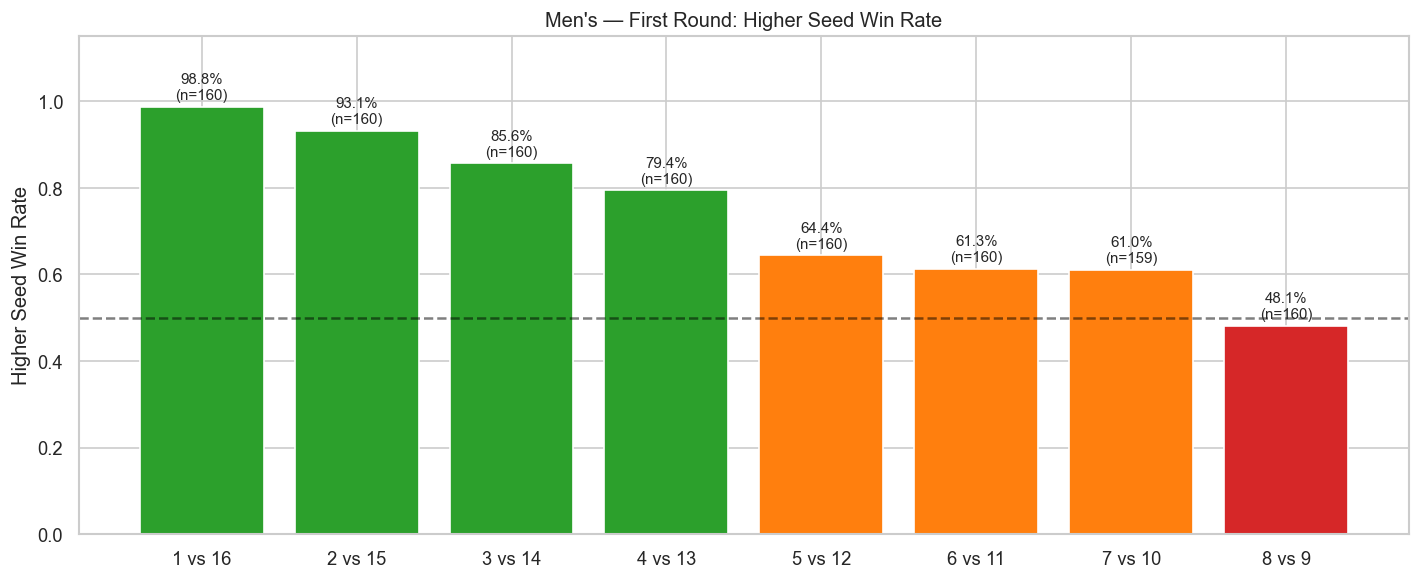

In [4]:
def first_round_winrates(tourney, seeds, label):
    seed_map = (
        seeds
        .with_columns(pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum'))
        .select(['Season', 'TeamID', 'SeedNum'])
    )
    games = (
        tourney
        .join(seed_map.rename({'TeamID': 'WTeamID', 'SeedNum': 'WSeed'}), on=['Season', 'WTeamID'], how='left')
        .join(seed_map.rename({'TeamID': 'LTeamID', 'SeedNum': 'LSeed'}), on=['Season', 'LTeamID'], how='left')
        .drop_nulls(['WSeed', 'LSeed'])
        .with_columns([
            pl.min_horizontal('WSeed', 'LSeed').alias('HigherSeed'),
            pl.max_horizontal('WSeed', 'LSeed').alias('LowerSeed'),
            (pl.col('WSeed') < pl.col('LSeed')).alias('HigherSeedWon'),
        ])
    ).to_pandas()

    first_round = [(1,16),(2,15),(3,14),(4,13),(5,12),(6,11),(7,10),(8,9)]
    rows = []
    for h, l in first_round:
        sub = games[(games['HigherSeed']==h) & (games['LowerSeed']==l)]
        if len(sub):
            rows.append({'Matchup': f'{h} vs {l}', 'WinRate': sub['HigherSeedWon'].mean(), 'n': len(sub)})
    df = pd.DataFrame(rows)

    colors = ['#2ca02c' if r >= 0.7 else '#ff7f0e' if r >= 0.5 else '#d62728' for r in df['WinRate']]
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(df['Matchup'], df['WinRate'], color=colors, edgecolor='white')
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5)
    for bar, (_, row) in zip(bars, df.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{row['WinRate']:.1%}\n(n={row['n']})", ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{label} — First Round: Higher Seed Win Rate', fontsize=12)
    ax.set_ylabel('Higher Seed Win Rate')
    plt.tight_layout()
    plt.show()

first_round_winrates(m_tourney, m_seeds, "Men's")

## 3. Score Margin Distributions: Tournament vs Regular Season

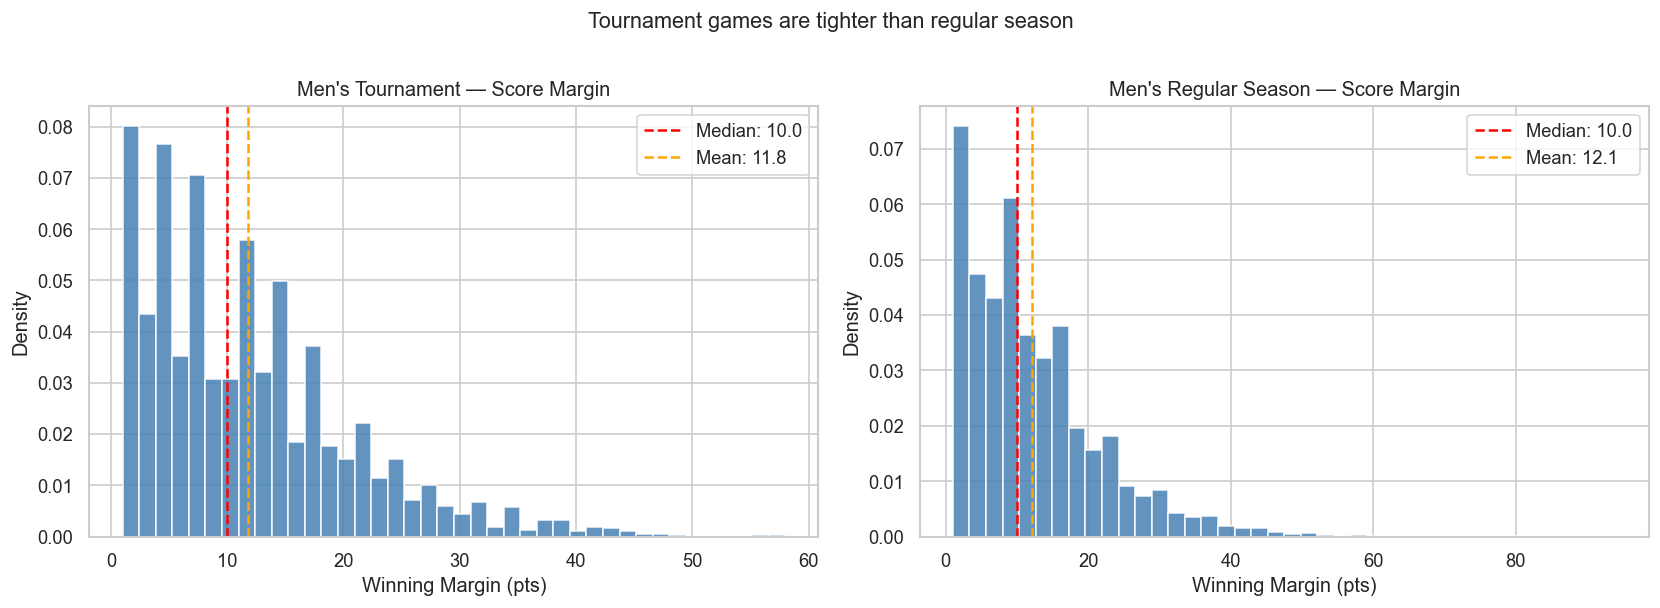

Tournament: median 10.0, % decided by <=5pts: 28.5%
Regular:   median 10.0, % decided by <=5pts: 28.3%


In [5]:
m_t_margins = (m_tourney['WScore'] - m_tourney['LScore']).to_numpy()
m_r_margins = (m_regular['WScore'] - m_regular['LScore']).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, margins, title in [
    (axes[0], m_t_margins, "Men's Tournament"),
    (axes[1], m_r_margins, "Men's Regular Season"),
]:
    ax.hist(margins, bins=40, color='steelblue', edgecolor='white', density=True, alpha=0.85)
    ax.axvline(np.median(margins), color='red', linestyle='--', label=f'Median: {np.median(margins):.1f}')
    ax.axvline(np.mean(margins), color='orange', linestyle='--', label=f'Mean: {np.mean(margins):.1f}')
    ax.set_title(f'{title} — Score Margin', fontsize=12)
    ax.set_xlabel('Winning Margin (pts)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Tournament games are tighter than regular season', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Tournament: median {np.median(m_t_margins):.1f}, % decided by <=5pts: {(m_t_margins<=5).mean():.1%}")
print(f"Regular:   median {np.median(m_r_margins):.1f}, % decided by <=5pts: {(m_r_margins<=5).mean():.1%}")

## 4. Upset Rate by Tournament Round

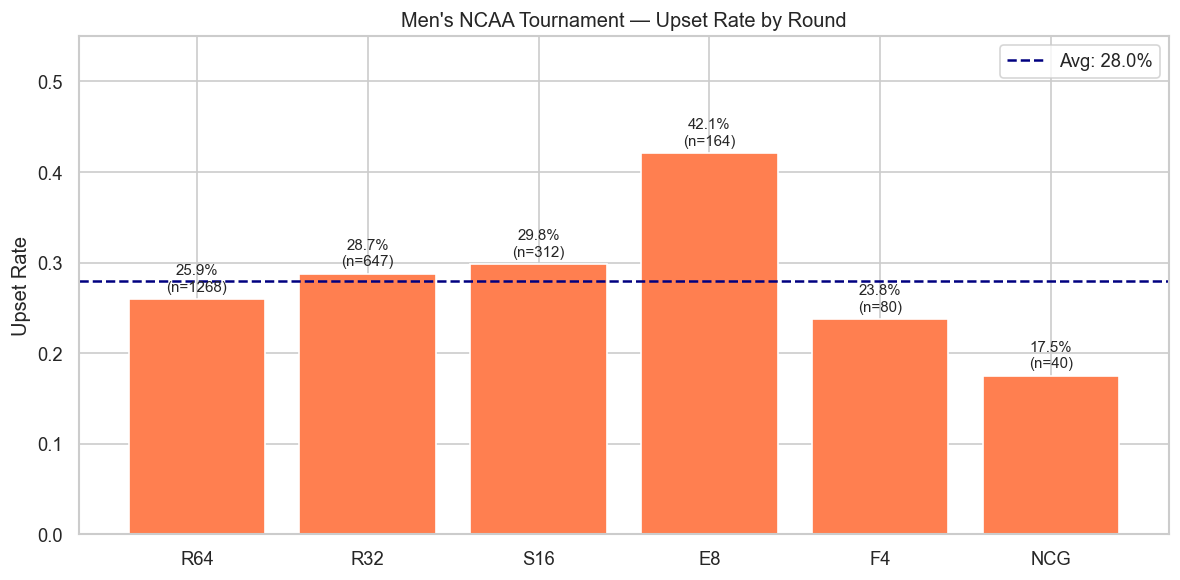

In [6]:
round_map = {136:'R64',137:'R64',138:'R32',139:'R32',
             143:'S16',144:'S16',145:'E8', 146:'E8',
             152:'F4', 154:'NCG',155:'NCG'}
round_order = ['R64','R32','S16','E8','F4','NCG']

def upset_by_round(tourney, seeds, label):
    seed_map = (
        seeds
        .with_columns(pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum'))
        .select(['Season','TeamID','SeedNum'])
    )
    games = (
        tourney
        .join(seed_map.rename({'TeamID':'WTeamID','SeedNum':'WSeed'}), on=['Season','WTeamID'], how='left')
        .join(seed_map.rename({'TeamID':'LTeamID','SeedNum':'LSeed'}), on=['Season','LTeamID'], how='left')
        .drop_nulls(['WSeed','LSeed'])
        .with_columns([
            (pl.col('WSeed') > pl.col('LSeed')).alias('Upset'),
            pl.col('DayNum').map_elements(lambda x: round_map.get(x, None), return_dtype=pl.String).alias('Round')
        ])
        .filter(pl.col('Round').is_in(round_order))
    )
    results = (
        games.group_by('Round')
        .agg([pl.len().alias('Games'), pl.col('Upset').mean().alias('UpsetRate')])
        .to_pandas()
    )
    results['Order'] = results['Round'].map({r:i for i,r in enumerate(round_order)})
    results = results.sort_values('Order')

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(results['Round'], results['UpsetRate'], color='coral', edgecolor='white')
    ax.axhline(results['UpsetRate'].mean(), color='navy', linestyle='--',
               label=f"Avg: {results['UpsetRate'].mean():.1%}")
    for _, row in results.iterrows():
        ax.text(row['Round'], row['UpsetRate']+0.006,
                f"{row['UpsetRate']:.1%}\n(n={int(row['Games'])})", ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, 0.55)
    ax.set_title(f'{label} — Upset Rate by Round', fontsize=12)
    ax.set_ylabel('Upset Rate')
    ax.legend()
    plt.tight_layout()
    plt.show()

upset_by_round(m_tourney, m_seeds, "Men's NCAA Tournament")

## 5. Average Points Per Team Per Game Over the Decades

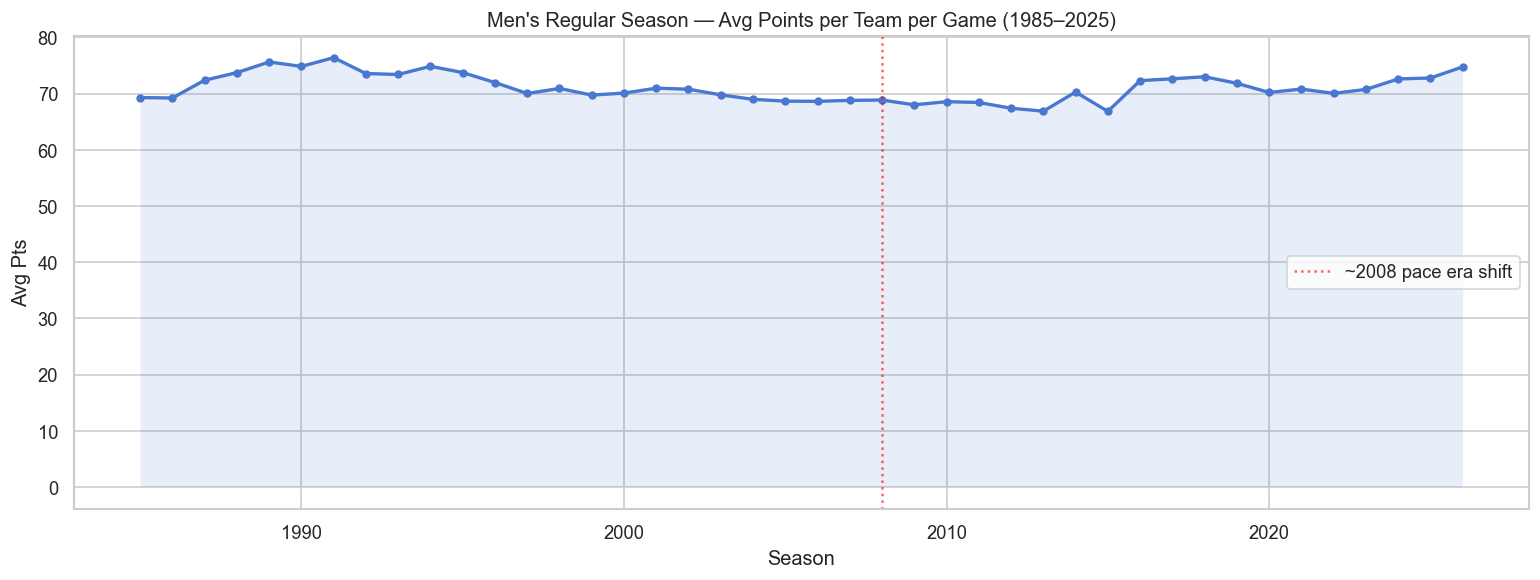

In [7]:
season_scores = (
    m_regular
    .with_columns(((pl.col('WScore')+pl.col('LScore'))/2).alias('AvgScore'))
    .group_by('Season')
    .agg(pl.col('AvgScore').mean().alias('AvgPtsPerTeam'))
    .sort('Season')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(season_scores['Season'], season_scores['AvgPtsPerTeam'], marker='o', markersize=4, linewidth=2)
ax.fill_between(season_scores['Season'], season_scores['AvgPtsPerTeam'], alpha=0.12)
ax.set_title("Men's Regular Season — Avg Points per Team per Game (1985–2025)", fontsize=12)
ax.set_xlabel('Season')
ax.set_ylabel('Avg Pts')
ax.axvline(2008, color='red', linestyle=':', alpha=0.6, label='~2008 pace era shift')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Regular Season Win % vs Tournament Seed

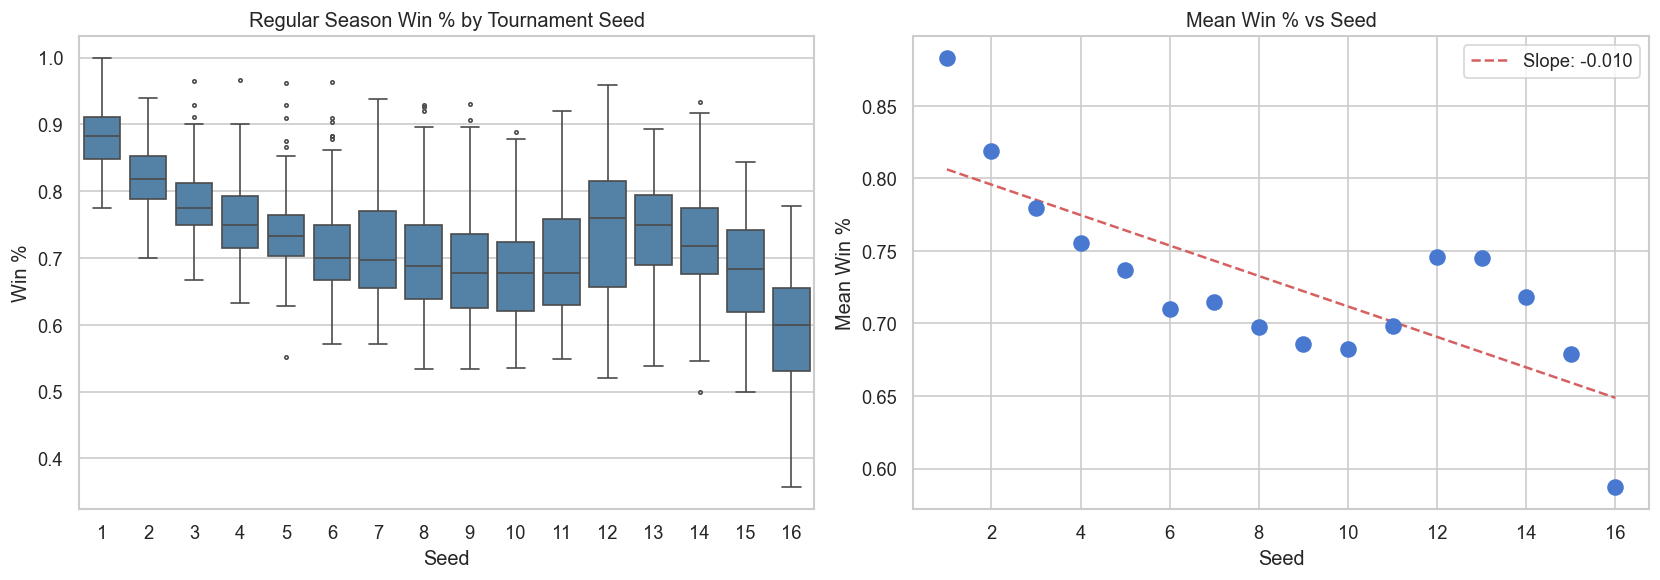

In [8]:
wins = m_regular.group_by(['Season','WTeamID']).agg(pl.len().alias('Wins')).rename({'WTeamID':'TeamID'})
losses = m_regular.group_by(['Season','LTeamID']).agg(pl.len().alias('Losses')).rename({'LTeamID':'TeamID'})

reg_perf = (
    wins.join(losses, on=['Season','TeamID'], how='full', coalesce=True)
    .with_columns([pl.col('Wins').fill_null(0), pl.col('Losses').fill_null(0)])
    .with_columns((pl.col('Wins')/(pl.col('Wins')+pl.col('Losses'))).alias('WinPct'))
)

seed_map = m_seeds.with_columns(
    pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum')
)
perf_w_seed = reg_perf.join(seed_map, on=['Season','TeamID'], how='inner').to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=perf_w_seed, x='SeedNum', y='WinPct', ax=axes[0], color='steelblue', fliersize=2)
axes[0].set_title('Regular Season Win % by Tournament Seed', fontsize=12)
axes[0].set_xlabel('Seed')
axes[0].set_ylabel('Win %')

means = perf_w_seed.groupby('SeedNum')['WinPct'].mean().reset_index()
axes[1].scatter(means['SeedNum'], means['WinPct'], s=80, zorder=5)
c = np.polyfit(means['SeedNum'], means['WinPct'], 1)
xl = np.linspace(1, 16, 100)
axes[1].plot(xl, np.polyval(c, xl), 'r--', label=f'Slope: {c[0]:.3f}')
axes[1].set_title('Mean Win % vs Seed', fontsize=12)
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Mean Win %')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Shooting Efficiency: Tournament Winners vs Losers

/var/folders/dm/xmt0kc7d45bbjbmvfs9tpy1r0000gn/T/ipykernel_79090/1829348429.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_t, x='Outcome', y=col, ax=ax,
/var/folders/dm/xmt0kc7d45bbjbmvfs9tpy1r0000gn/T/ipykernel_79090/1829348429.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_t, x='Outcome', y=col, ax=ax,
/var/folders/dm/xmt0kc7d45bbjbmvfs9tpy1r0000gn/T/ipykernel_79090/1829348429.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_t, x='Outcome', y=col, ax=ax,


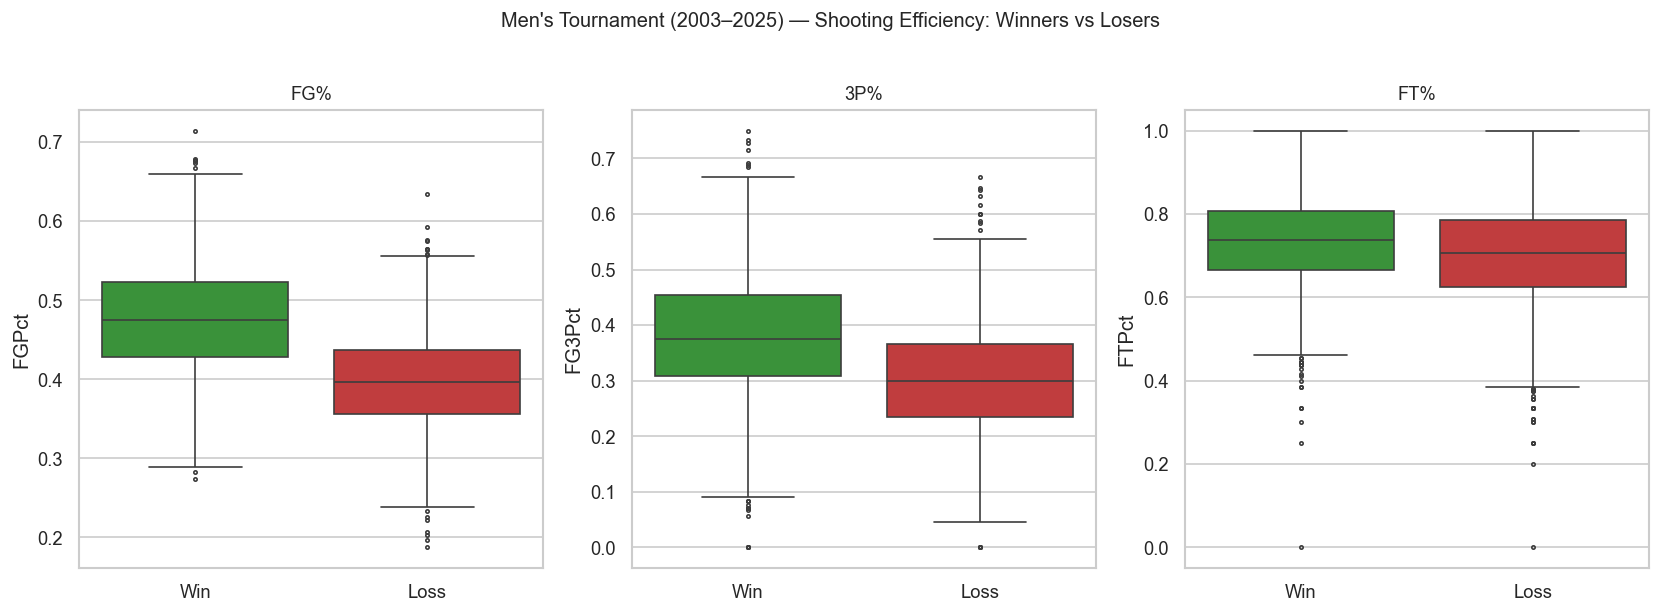

In [9]:
winners = m_tourney_d.select([
    'Season',
    pl.col('WFGM').alias('FGM'), pl.col('WFGA').alias('FGA'),
    pl.col('WFGM3').alias('FGM3'), pl.col('WFGA3').alias('FGA3'),
    pl.col('WFTM').alias('FTM'), pl.col('WFTA').alias('FTA'),
    pl.lit('Win').alias('Outcome')
])
losers = m_tourney_d.select([
    'Season',
    pl.col('LFGM').alias('FGM'), pl.col('LFGA').alias('FGA'),
    pl.col('LFGM3').alias('FGM3'), pl.col('LFGA3').alias('FGA3'),
    pl.col('LFTM').alias('FTM'), pl.col('LFTA').alias('FTA'),
    pl.lit('Loss').alias('Outcome')
])

all_t = pl.concat([winners, losers]).with_columns([
    (pl.col('FGM')/pl.col('FGA')).alias('FGPct'),
    (pl.col('FGM3')/pl.col('FGA3')).alias('FG3Pct'),
    (pl.col('FTM')/pl.col('FTA')).alias('FTPct'),
]).to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, title in [
    (axes[0],'FGPct','FG%'),
    (axes[1],'FG3Pct','3P%'),
    (axes[2],'FTPct','FT%'),
]:
    sns.boxplot(data=all_t, x='Outcome', y=col, ax=ax,
                palette={'Win':'#2ca02c','Loss':'#d62728'}, fliersize=2)
    ax.set_title(f'{title}', fontsize=11)
    ax.set_xlabel('')

plt.suptitle("Men's Tournament (2003–2025) — Shooting Efficiency: Winners vs Losers", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Men's vs Women's — How Predictable are Seeds?

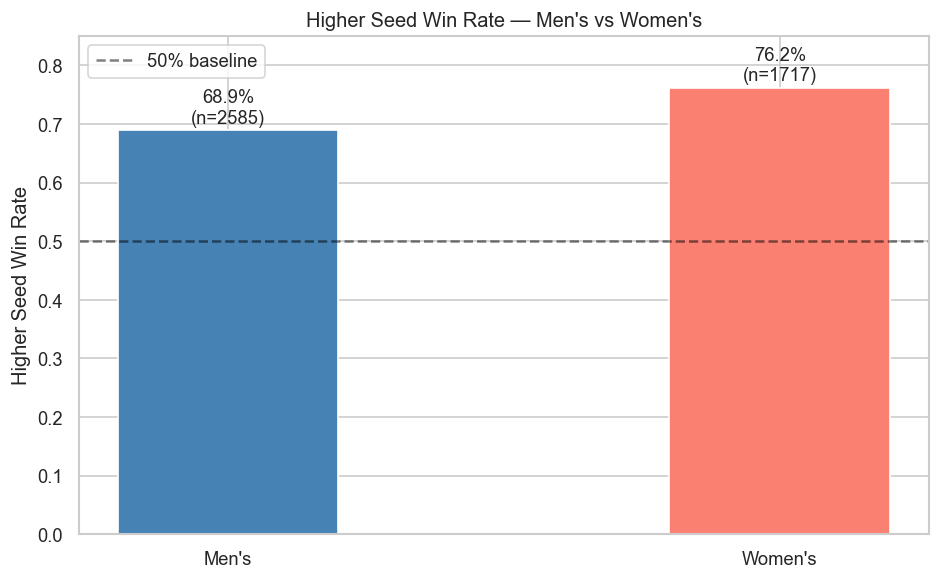

Men's: 68.9% | Women's: 76.2%


In [10]:
def higher_seed_winrate(tourney, seeds):
    seed_map = (
        seeds
        .with_columns(pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum'))
        .select(['Season','TeamID','SeedNum'])
    )
    games = (
        tourney
        .join(seed_map.rename({'TeamID':'WTeamID','SeedNum':'WSeed'}), on=['Season','WTeamID'], how='left')
        .join(seed_map.rename({'TeamID':'LTeamID','SeedNum':'LSeed'}), on=['Season','LTeamID'], how='left')
        .drop_nulls(['WSeed','LSeed'])
        .with_columns((pl.col('WSeed') < pl.col('LSeed')).alias('HigherSeedWon'))
    )
    return games['HigherSeedWon'].mean(), len(games)

m_rate, m_n = higher_seed_winrate(m_tourney, m_seeds)
w_rate, w_n = higher_seed_winrate(w_tourney, w_seeds)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(["Men's","Women's"], [m_rate, w_rate],
              color=['steelblue','salmon'], width=0.4, edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50% baseline')
for bar, rate, n in zip(bars, [m_rate, w_rate], [m_n, w_n]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 0.85)
ax.set_title("Higher Seed Win Rate — Men's vs Women's", fontsize=12)
ax.set_ylabel('Higher Seed Win Rate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Men's: {m_rate:.1%} | Women's: {w_rate:.1%}")

## 9. Champion Seeds Over Time

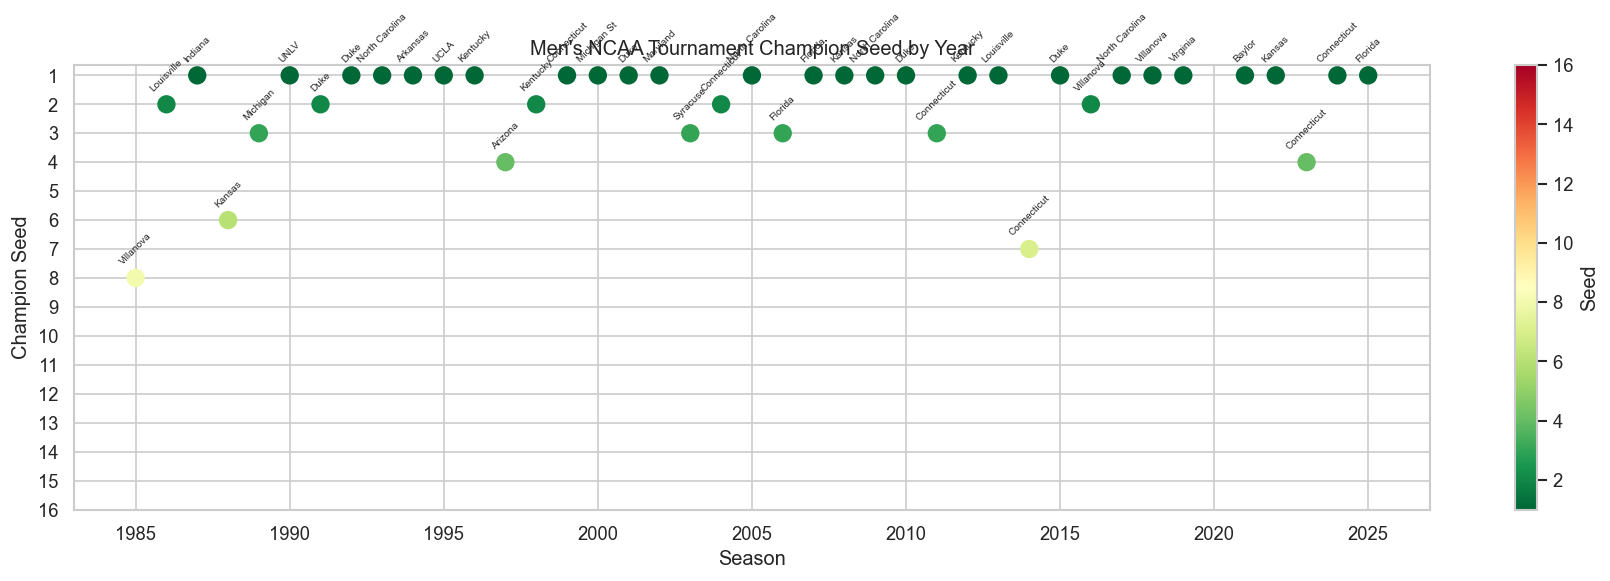

Non-1-seed champions:
 Season    TeamName  SeedNum
   1985   Villanova        8
   1986  Louisville        2
   1988      Kansas        6
   1989    Michigan        3
   1991        Duke        2
   1997     Arizona        4
   1998    Kentucky        2
   2003    Syracuse        3
   2004 Connecticut        2
   2006     Florida        3
   2011 Connecticut        3
   2014 Connecticut        7
   2016   Villanova        2
   2023 Connecticut        4


In [11]:
seed_map = (
    m_seeds
    .with_columns(pl.col('Seed').map_elements(parse_seed, return_dtype=pl.Int32).alias('SeedNum'))
    .select(['Season','TeamID','SeedNum'])
)
champs = (
    m_tourney
    .sort('DayNum', descending=True)
    .group_by('Season').first()
    .select(['Season','WTeamID'])
    .join(seed_map.rename({'TeamID':'WTeamID'}), on=['Season','WTeamID'], how='left')
    .join(m_teams.rename({'TeamID':'WTeamID'}), on='WTeamID', how='left')
    .sort('Season')
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(15,5))
sc = ax.scatter(champs['Season'], champs['SeedNum'], c=champs['SeedNum'],
                cmap='RdYlGn_r', s=100, vmin=1, vmax=16, zorder=5)
ax.invert_yaxis()
ax.set_yticks(range(1,17))
ax.set_title("Men's NCAA Tournament Champion Seed by Year", fontsize=12)
ax.set_xlabel('Season')
ax.set_ylabel('Champion Seed')
for _, row in champs.iterrows():
    if pd.notna(row.get('TeamName')):
        ax.annotate(row['TeamName'], (row['Season'], row['SeedNum']),
                    xytext=(0,8), textcoords='offset points',
                    ha='center', fontsize=6, rotation=45)
plt.colorbar(sc, ax=ax, label='Seed')
plt.tight_layout()
plt.show()

print('Non-1-seed champions:')
print(champs[champs['SeedNum']>1][['Season','TeamName','SeedNum']].to_string(index=False))

## 10. Submission Format

In [12]:
sub = pl.read_csv(f'{DATA}/SampleSubmissionStage1.csv')
print('Shape:', sub.shape)
display(sub.head(5).to_pandas())
print('ID format:', sub['ID'][0], '  -> Season_LowerTeamID_HigherTeamID')
seasons = sub['ID'].str.slice(0,4).unique().sort().to_list()
print('Seasons to predict:', seasons)

Shape: (519144, 2)


,ID,Pred
0,2022_1101_1102,0.5
1,2022_1101_1103,0.5
2,2022_1101_1104,0.5
3,2022_1101_1105,0.5
4,2022_1101_1106,0.5


ID format: 2022_1101_1102   -> Season_LowerTeamID_HigherTeamID
Seasons to predict: ['2022', '2023', '2024', '2025']
